# RMT Playground

Examples for the Gauss-Wigner and Wishart-Laguerre ensemble classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.modules.GW_Ensemble import GW_Ensemble
from src.modules.WL_Ensemble import WL_Ensemble

plt.rc('figure', figsize=(16,6))
plt.rc('savefig', dpi=90)
plt.rc('font', family='sans-serif')
plt.rc('font', size=14)
sns.set_style('darkgrid')

## Gauss-Wigner Ensemble

In [2]:
######## Gauss-Wigner Ensemble ########
## Simulate a large instance of the Gaussian Symplectic Ensemble
seed = 1776
ndim = 1000
beta = 4
rng = np.random.default_rng(seed=seed)

## Conjure the four builfing components
X11 = rng.standard_normal(size=[ndim,ndim])
X12 = rng.standard_normal(size=[ndim,ndim])
X21 = rng.standard_normal(size=[ndim,ndim])
X22 = rng.standard_normal(size=[ndim,ndim])

## Cast the four real matrices into two pairs of complex matrices
X1 = X11 + 1j * X12
X2 = X21 + 1j * X22

## Forge the quaternionic matrix
X = np.block([ [X1, X2] ,[-X2.conj(), X1] ])

## Mold the newly craft quaternionic matrix into a self-dual matrix
G = (X + X.conj().T) / 2

## Invoke the Gauss-Wigner Symplectic Ensemble
GSE = GW_Ensemble(G, beta) 

In [3]:
#### For simulation, instead of simulating a single big instance of dimension ndim,
#### simulate 200 (2x) ndim*5/1000 dimensional quaternionic self-dual matrices from the GSE
#### !NOTE: The (2x) factor stands for the fact that quaternionic self-dual matrices are
####        2xN dimensional by construction, whereas the dimension of the sytem is N.
s_ndim = ndim/1000 * 5
GSE.simulate(ndim=s_ndim, beta=beta, nsim=200)

/tmp/ipykernel_1074273/1776658453.py:6: Warning: ndim is different from the dimension of the endog matrix.
  GSE.simulate(ndim=s_ndim, beta=beta, nsim=200)


/home/tl/Documents/Repos/rmt-x-py/src/modules/GW_Ensemble.py:21: RuntimeWarning: invalid value encountered in sqrt
  sc_density = lambda x: 1/np.pi * np.sqrt( 2 - x**2 )


<Axes: title={'center': 'Scree Plot of Sorted Eigenvalues'}, xlabel='$x$', ylabel='Sorted Eigenvalues'>

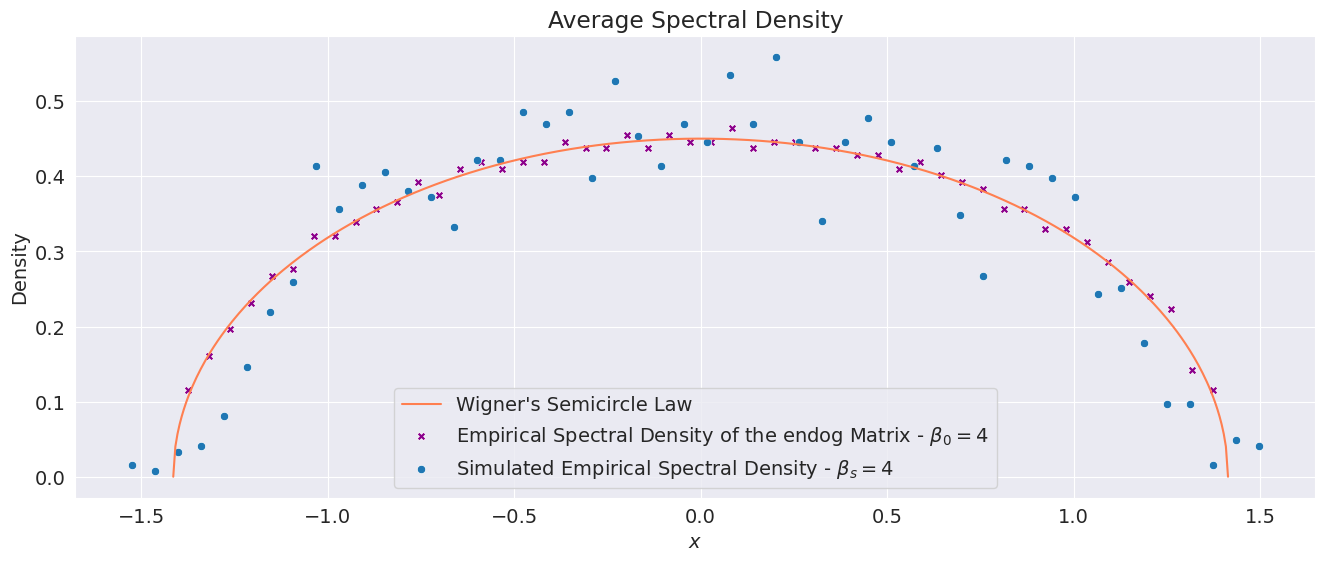

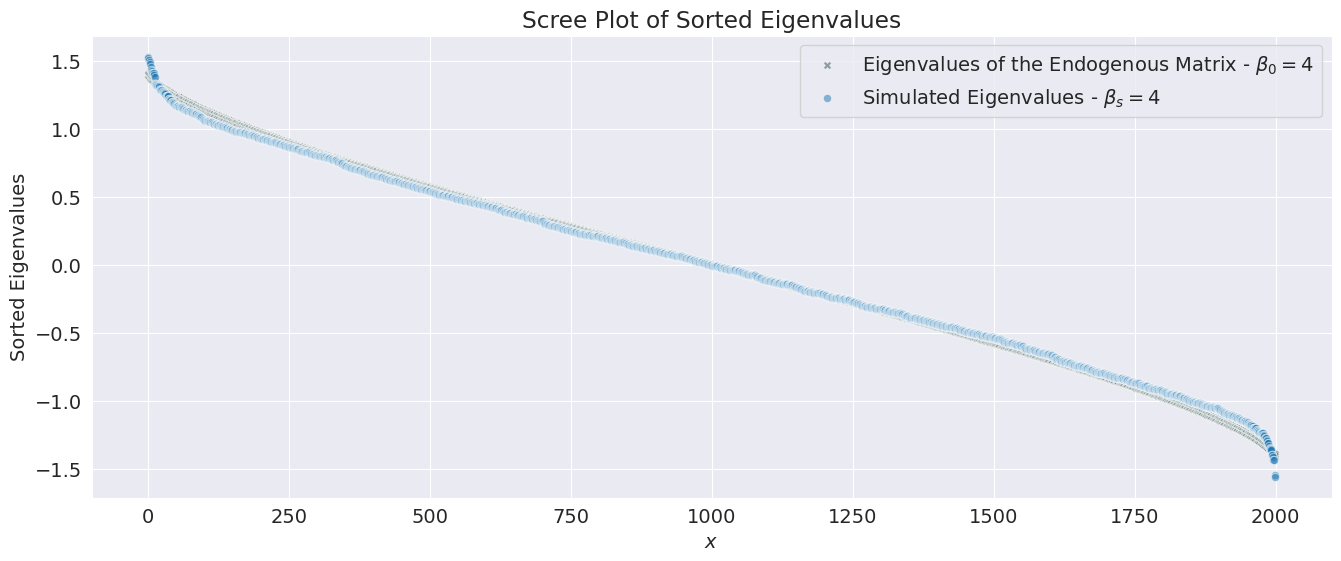

In [4]:
#### Visualizations
## Plot the spectrum and the scree plot of the endog matrix and the simulated ensemble
GSE.plot_spectrum()
GSE.plot_scree()

## Wishart-Laguerre Ensemble

In [5]:
######## Wishart-Laguerre Ensemble ########
## We study three different cases of the Laguerre Orthogonal Ensemble (LOE) - beta = 1
#    1. The case of a spherical covariance matrix with zero-correlations, i.e., a scalar multiple of the identity
#    2. The case of a non-spherical covariance matrix with zero-correlations, i.e., a diagonal non-spherical matrix
#    3. The case of a non-spherical covariance matrix with non-zero correlations, i.e., a general positive definite matrix
## In each case we simulate sample data from the multivariate zero-mean normal distribution
## and compare the spectral properties of:
#    - The Population covariance matrix
#    - The sample covariance matrix
#    - The Ledoit-Wolf Linear Shrinkage estimator

### Case 1: spherical covariance matrix

In [6]:
#### Case 1
## To make things more interesting, we fit a univariate Gaussian GARCH(1,1) model
## to the daily returns of the S&P500 index and use the model's unconditional variance
## as the random scalar to multiply the identity with. Alternatively, one could draw
## a random scalar from any distribution over the positive segment of its support.
## For retrieving the data on the daily returns of the S&P500 index and fitting 
## the GARCH model, need to have yfinance and arch installed as well.
import yfinance as yf
from arch import arch_model

In [7]:
'''
Load Data from Yahoo Finance
'''
symbol = '^GSPC'
start_date = '2016-03-01'
end_date = '2026-03-01'
spx = yf.Ticker(symbol).history(start=start_date, end=end_date)
rs = np.log(spx.Close).diff().dropna() * 100
## Drop all rows where returns are zero
rs = rs[rs != 0]

In [8]:
## Minimal model definition
md = arch_model(rs, vol='GARCH')
md_fit = md.fit()

#### Unconditional variance
## This is given in the GARCH(1,1) model by:
#    lamb = omega / (1 - alpha - beta)
lamb = md_fit.params['omega'] / (1 - md_fit.params['alpha[1]'] - md_fit.params['beta[1]'])

Iteration:      1,   Func. Count:      6,   Neg. LLF: 25044.392698166135
Iteration:      2,   Func. Count:     16,   Neg. LLF: 14538.766201985687
Iteration:      3,   Func. Count:     26,   Neg. LLF: 5204.943562276604
Iteration:      4,   Func. Count:     33,   Neg. LLF: 3404.910131173278
Iteration:      5,   Func. Count:     39,   Neg. LLF: 11581.702864851046
Iteration:      6,   Func. Count:     45,   Neg. LLF: 3264.2426891828077
Iteration:      7,   Func. Count:     51,   Neg. LLF: 3214.1794667272197
Iteration:      8,   Func. Count:     56,   Neg. LLF: 3214.140074945869
Iteration:      9,   Func. Count:     61,   Neg. LLF: 3214.1207510495924
Iteration:     10,   Func. Count:     66,   Neg. LLF: 3214.1174005990642
Iteration:     11,   Func. Count:     71,   Neg. LLF: 3214.117343713525
Iteration:     12,   Func. Count:     75,   Neg. LLF: 3214.1173437114717
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3214.117343713525
            Iteratio

In [9]:
#### We now create an instance of the ensemble
## !NOTE: Different values for ndim and nsim lead to very different results! This
##        is because the concentration ratio defined as c = ndim/nsim plays a huge
##        role in the behavior of the ensembles. This ratio is the key parameter in 
##        the analysis of Wishart-Laguerre ensembles.
ndim = 200
nsim = 240  ## simulated sample size
beta = 1
L = np.eye(ndim) * lamb

## Round the cov matrix so as not to run in to numerical approximation related errors
L = np.round(L, decimals=2)

LOE = WL_Ensemble(L, beta)
LOE.simulate(nsim=nsim)

array([<Axes: title={'center': 'Heatmap of the Population Covariance Matrix'}>,
       <Axes: title={'center': 'Heatmap of the Ledoit-Wolf LS Estimator\nShrinkage Intensity = 0.99'}>],
      dtype=object)

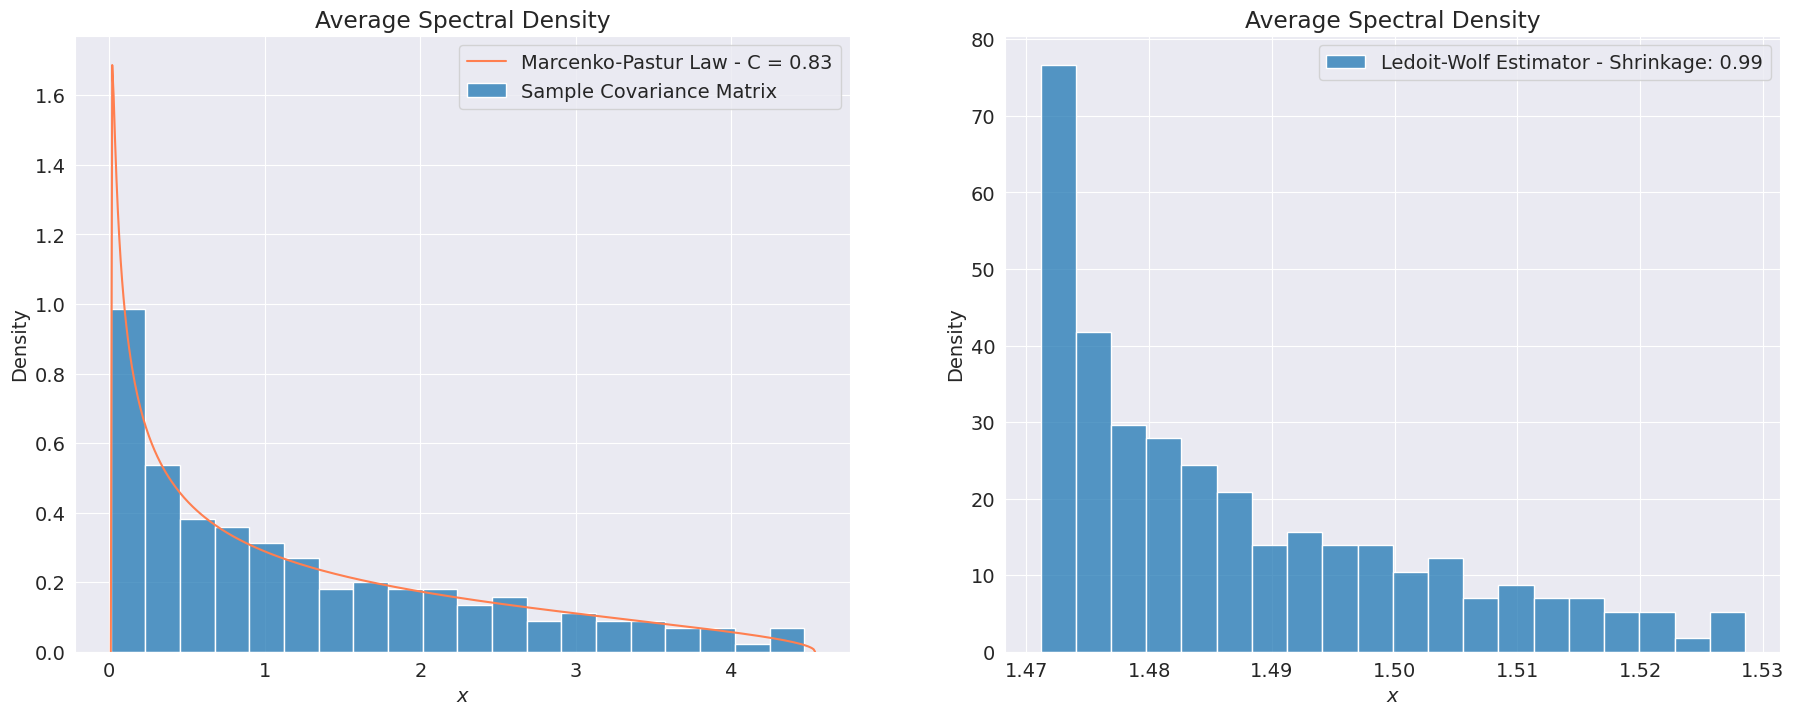

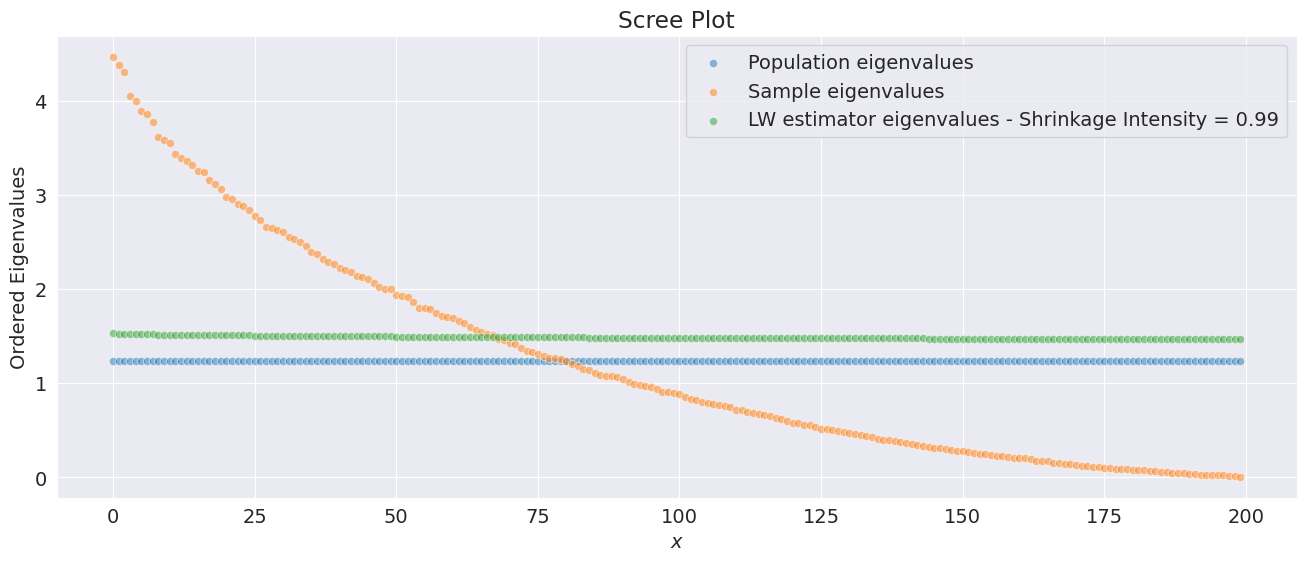

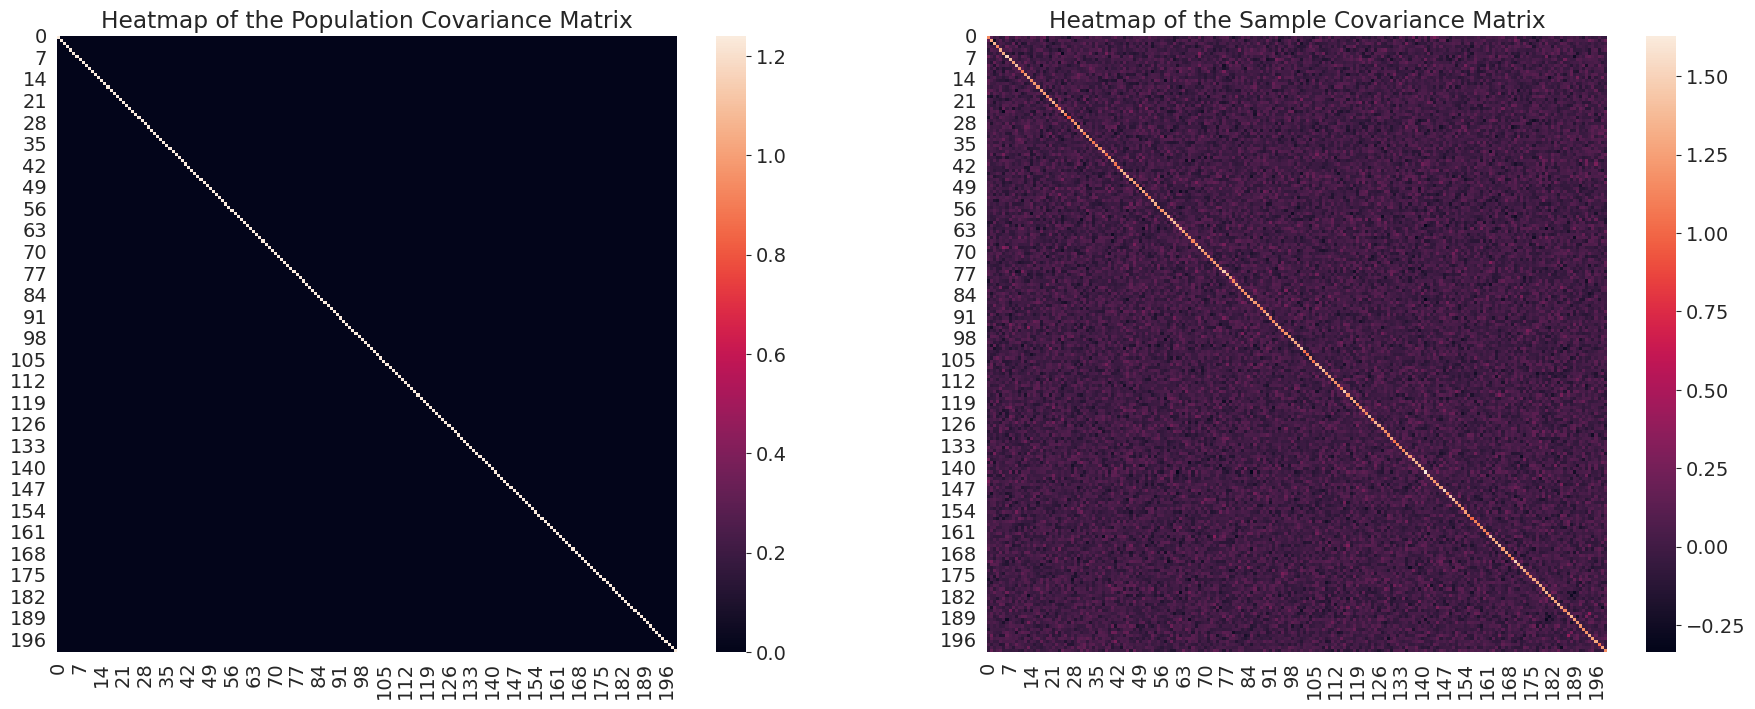

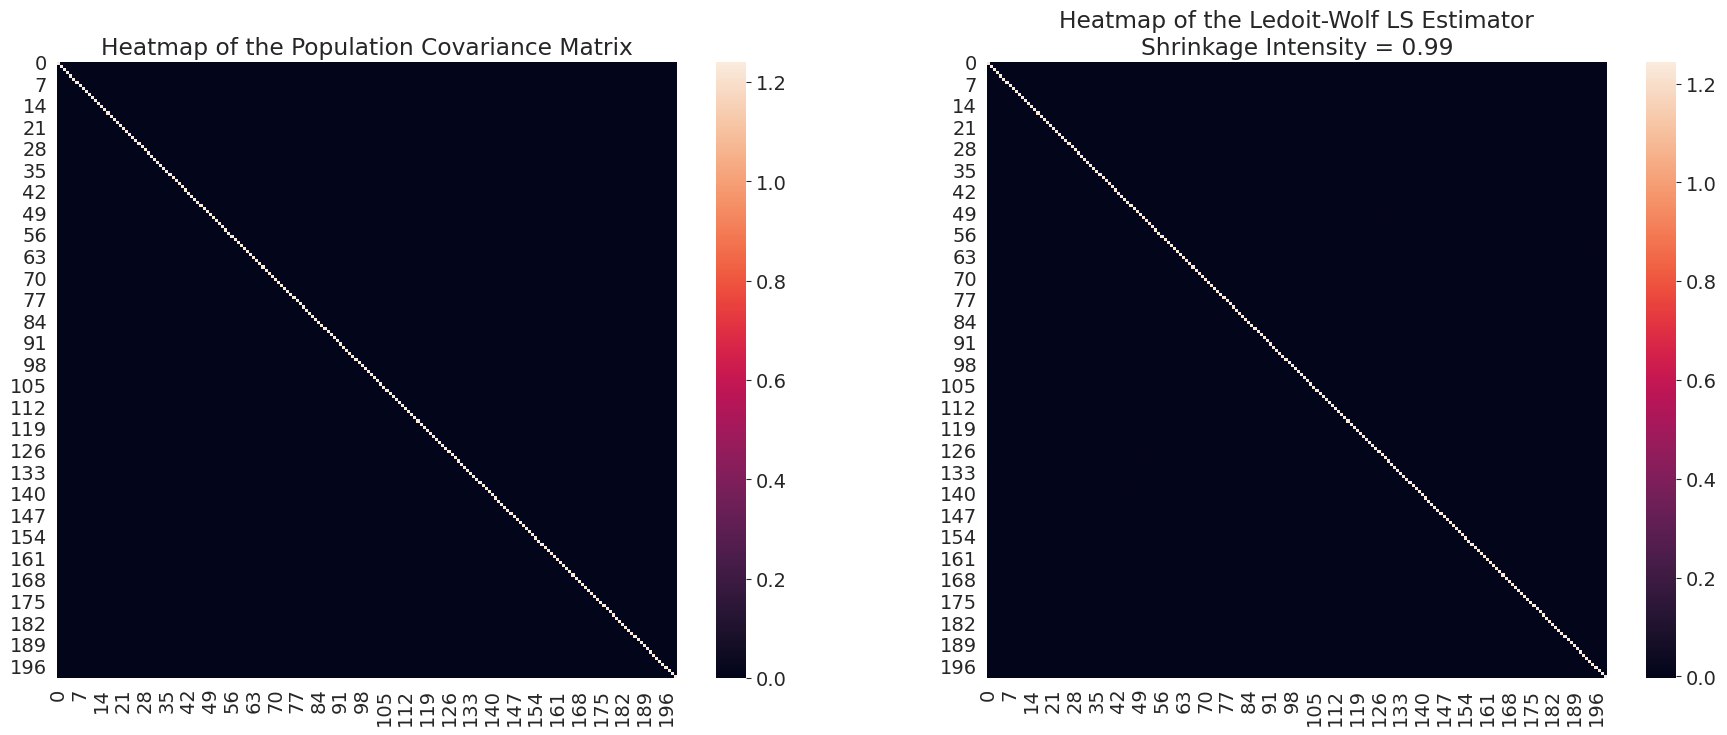

In [10]:
#### Visualizations
## Plot the spectrum and the scree plot of all three matrices
LOE.plot_spectrum(plot_type='histogram')
LOE.plot_scree()

## For the Wishart-Laguerre ensemble the heatmaps of the matrices is also available
LOE.plot_heatmap(cov_matrix='sample_cov') ## Compare Population vs Sample cov matrix
LOE.plot_heatmap(cov_matrix='lw_cov')     ## Compare Population cov matric ws Ledoit-Wolf LS estimator

### Case 2: diagonal non-spherical covariance matrix

In [11]:
#### Case 2
## Simulate a diagonal covariance matrix from the unifrom distribution with 
## the lower and upper bounds given by the unconditional covariance of the GARCH model
## computed above as
u_lower = lamb
u_upper = lamb * 2
L = rng.uniform(low=u_lower, high=u_upper, size = ndim)
L = np.diag(L)

## Round the cov matrix so as not to run in to numerical approximation related errors
L = np.round(L, decimals=2)

LOE = WL_Ensemble(L, beta)
LOE.simulate(nsim=nsim)

array([<Axes: title={'center': 'Heatmap of the Population Covariance Matrix'}>,
       <Axes: title={'center': 'Heatmap of the Ledoit-Wolf LS Estimator\nShrinkage Intensity = 0.95'}>],
      dtype=object)

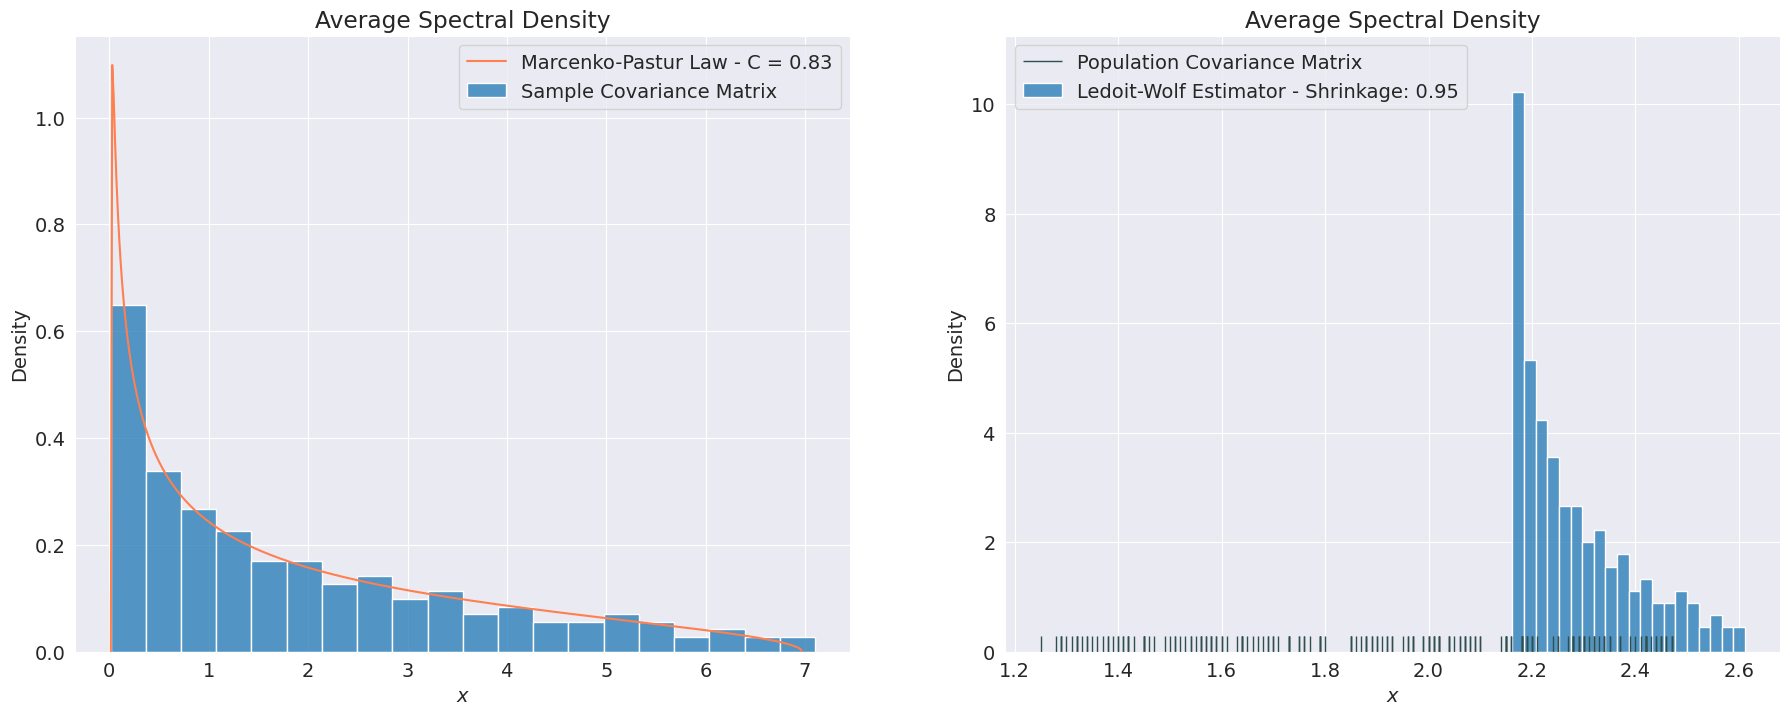

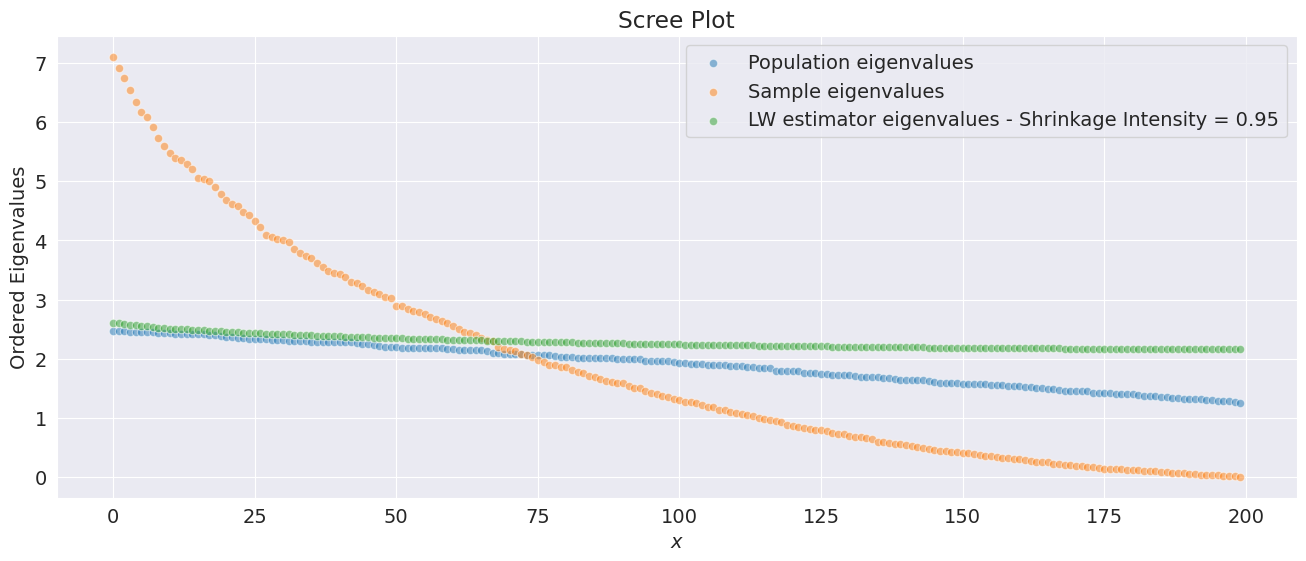

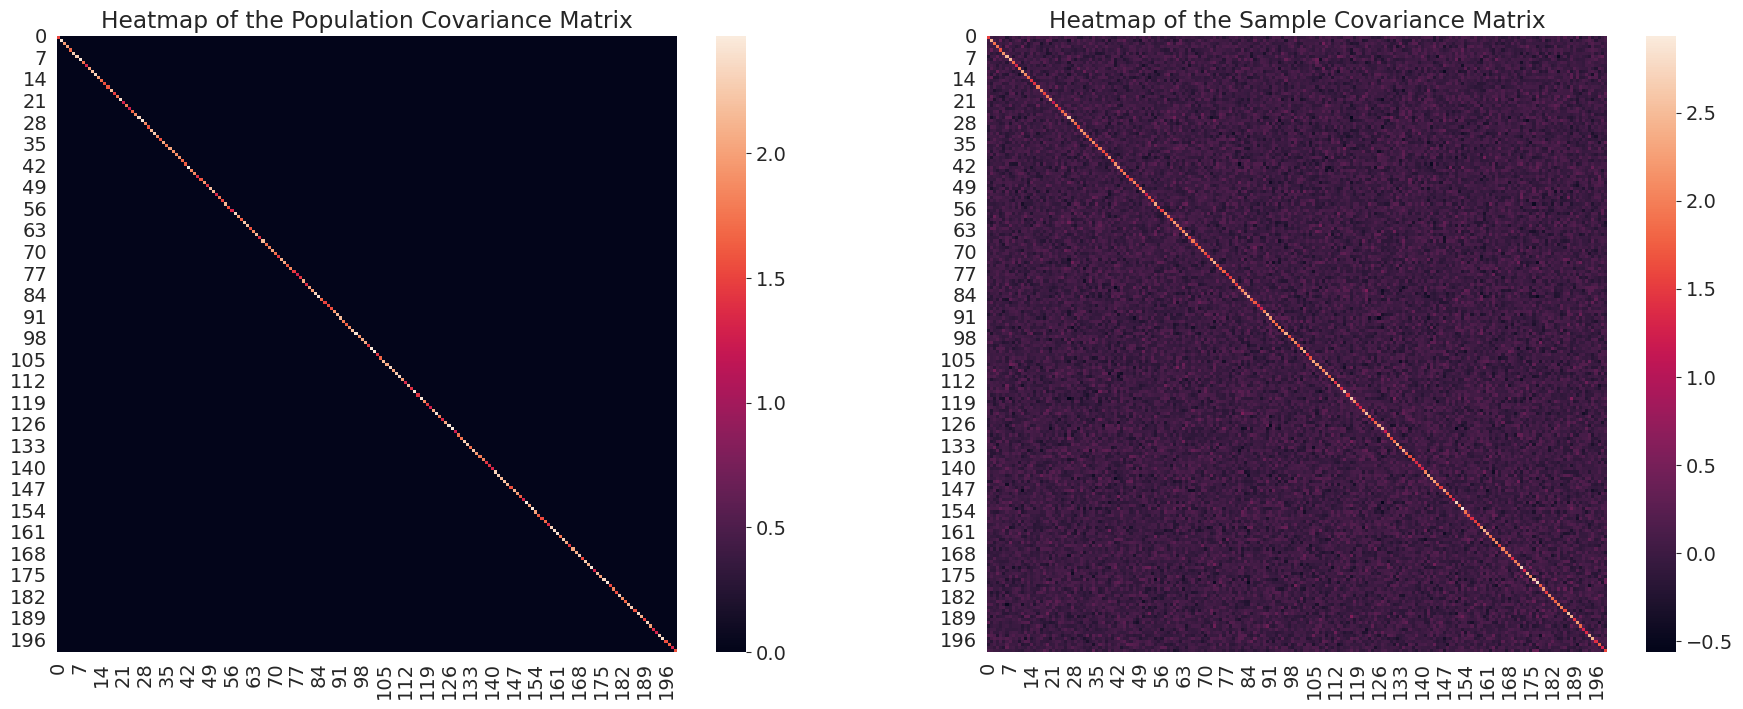

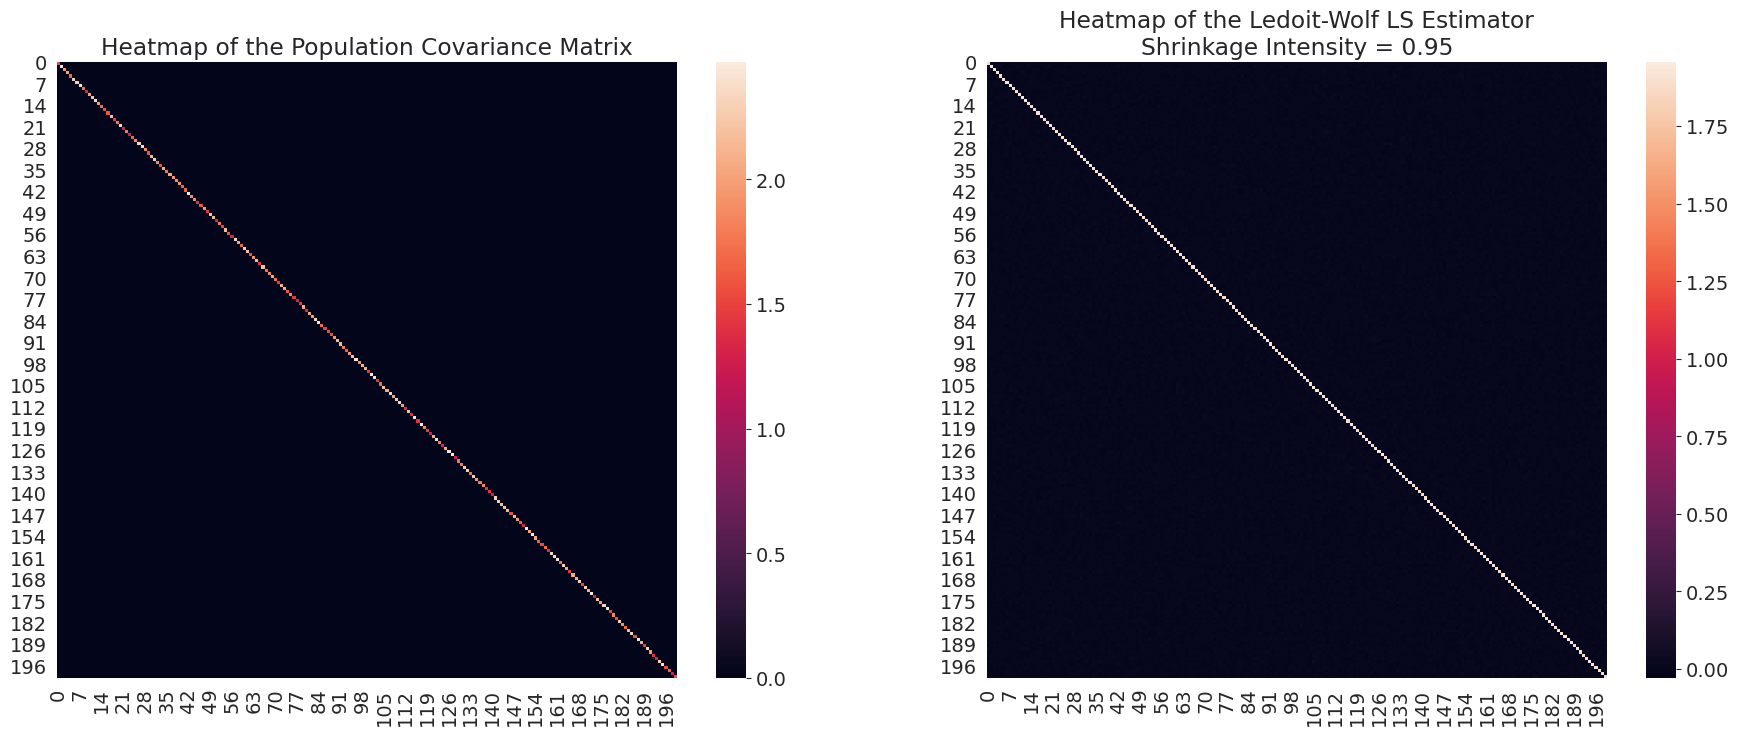

In [12]:
#### Visualizations
LOE.plot_spectrum(plot_type='histogram')
LOE.plot_scree()
LOE.plot_heatmap(cov_matrix='sample_cov') ## Compare Population vs Sample cov matrix
LOE.plot_heatmap(cov_matrix='lw_cov')     ## Compare Population cov matric ws Ledoit-Wolf LS estimator

### Case 3: general positive definite covariance matrix

In [13]:
#### Case 3
## Simulate a non-spherical, non-zero-correlation covariance matrix
## Simulate matrix of eigenvectors from the Haar distribution and the 
## eigenvalues from the uniform with lower and upper bounds set as before.
Q, R = np.linalg.qr(rng.standard_normal((ndim, ndim)))
Q *= np.sign(np.diag(R))
ev = rng.uniform(u_lower, u_upper, size=ndim)
L = (Q * ev) @ Q.T
L =  (L + L.T) / 2

## Round the cov matrix so as not to run in to numerical approximation related errors
L = np.round(L, decimals=2)

LOE = WL_Ensemble(L, beta)
LOE.simulate(nsim=nsim)

array([<Axes: title={'center': 'Heatmap of the Population Covariance Matrix'}>,
       <Axes: title={'center': 'Heatmap of the Ledoit-Wolf LS Estimator\nShrinkage Intensity = 0.94'}>],
      dtype=object)

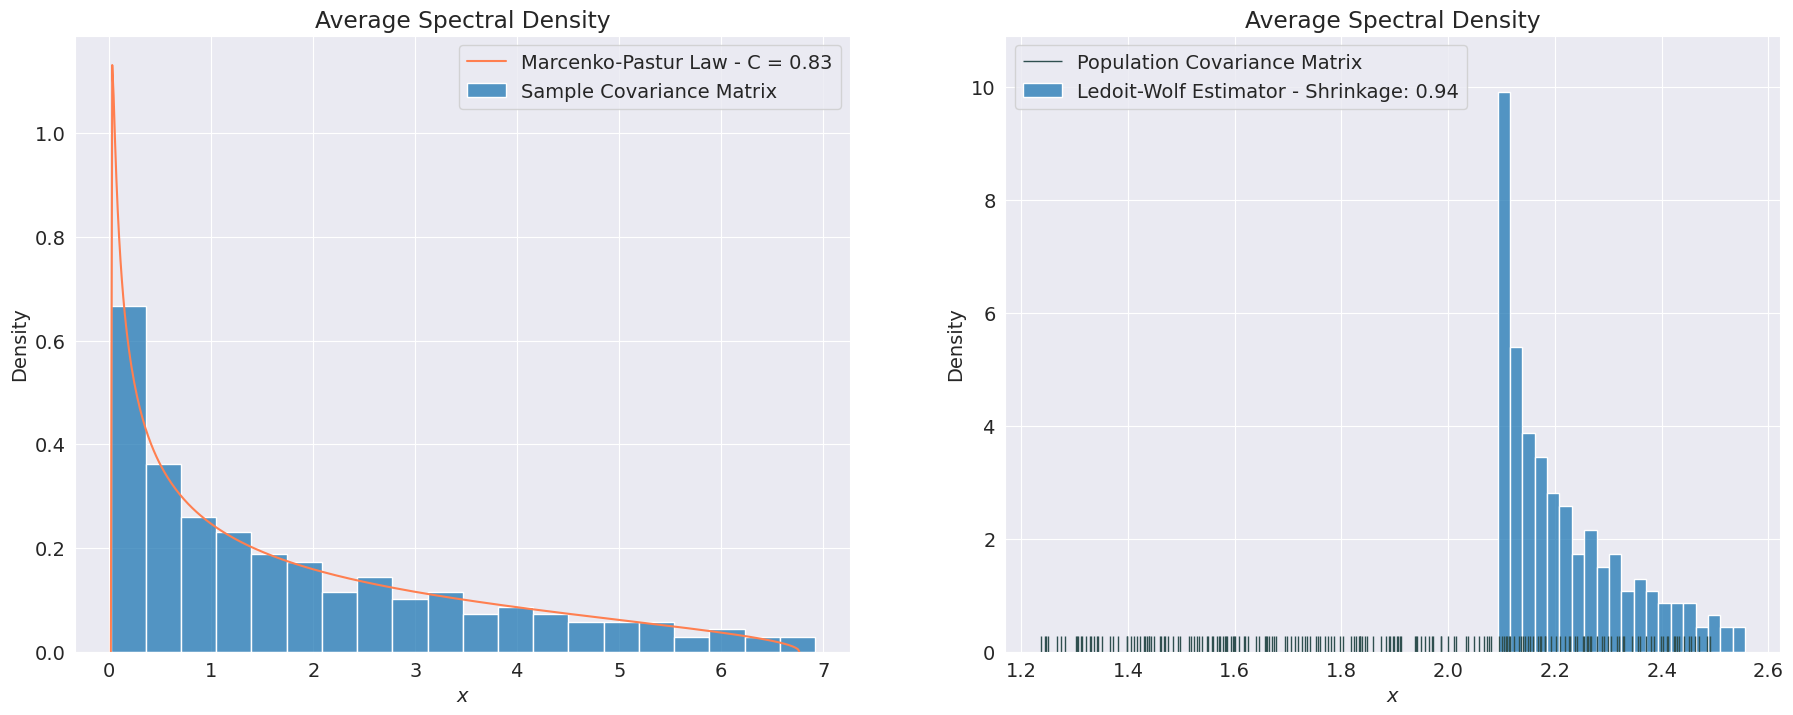

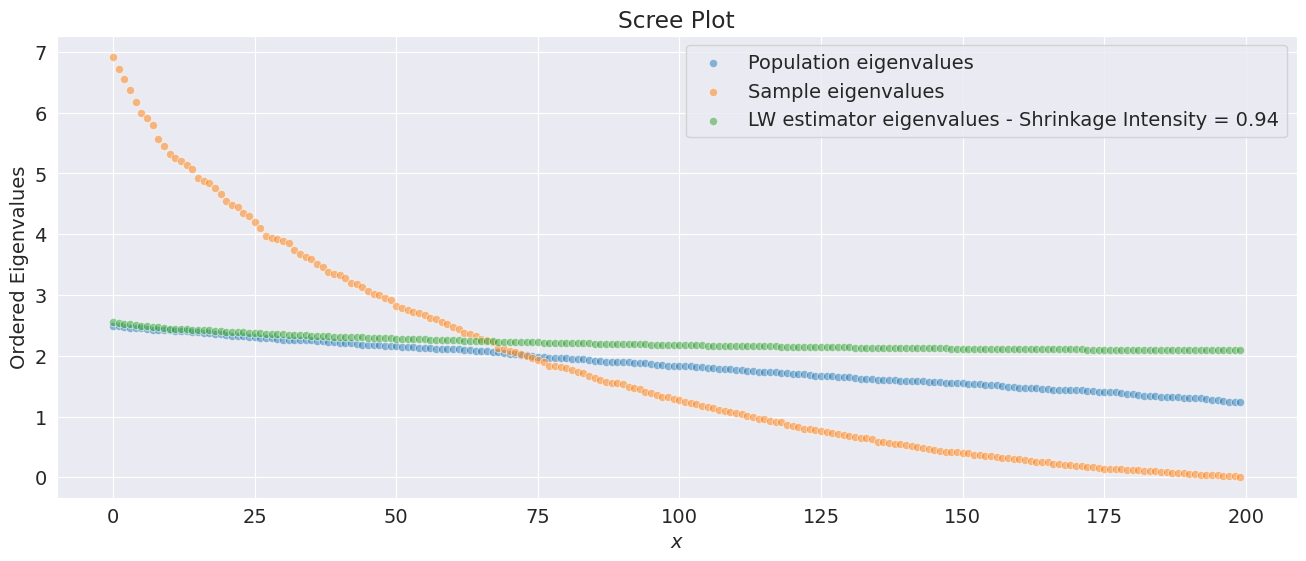

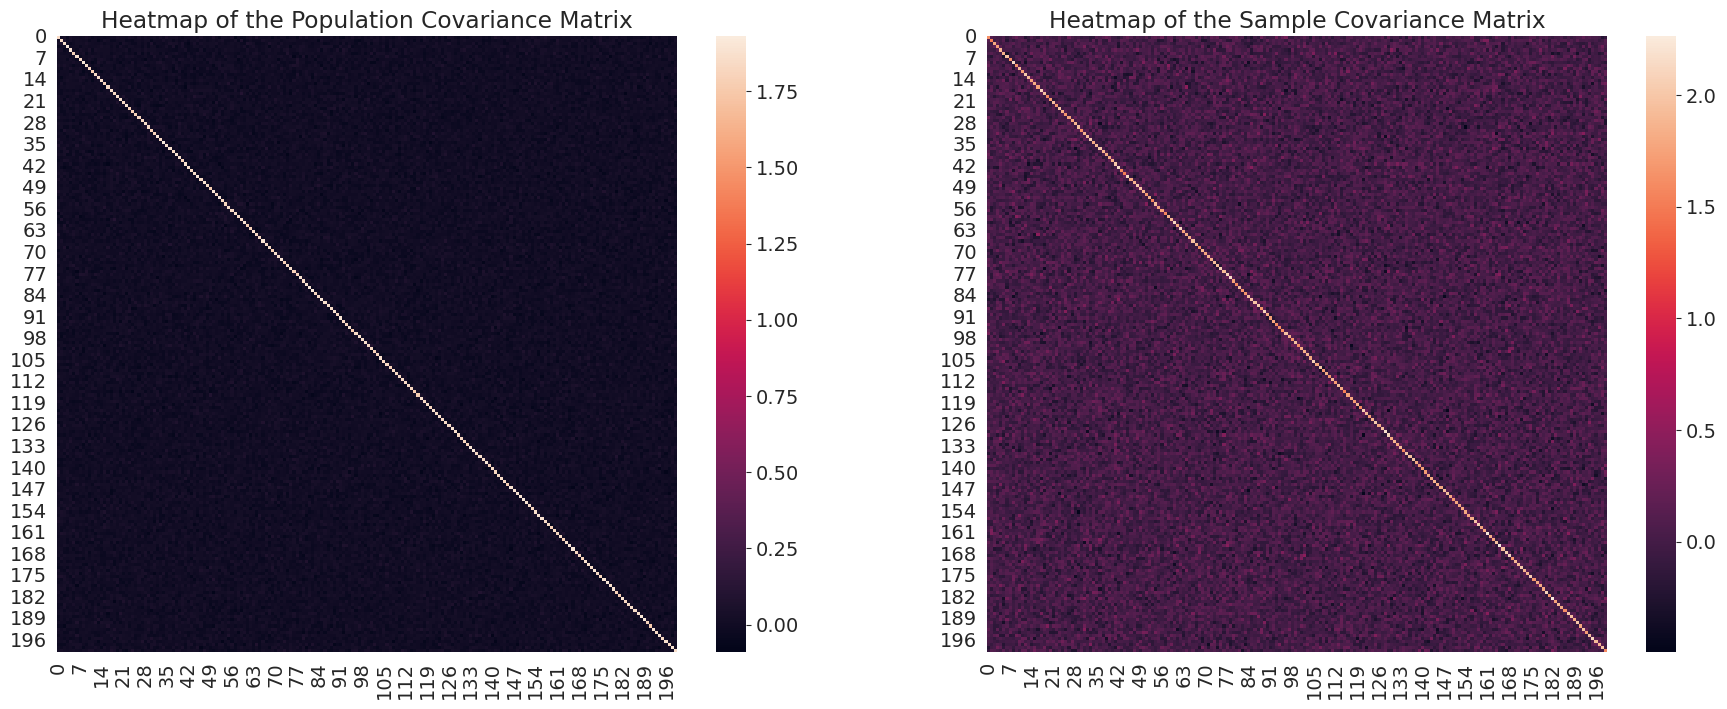

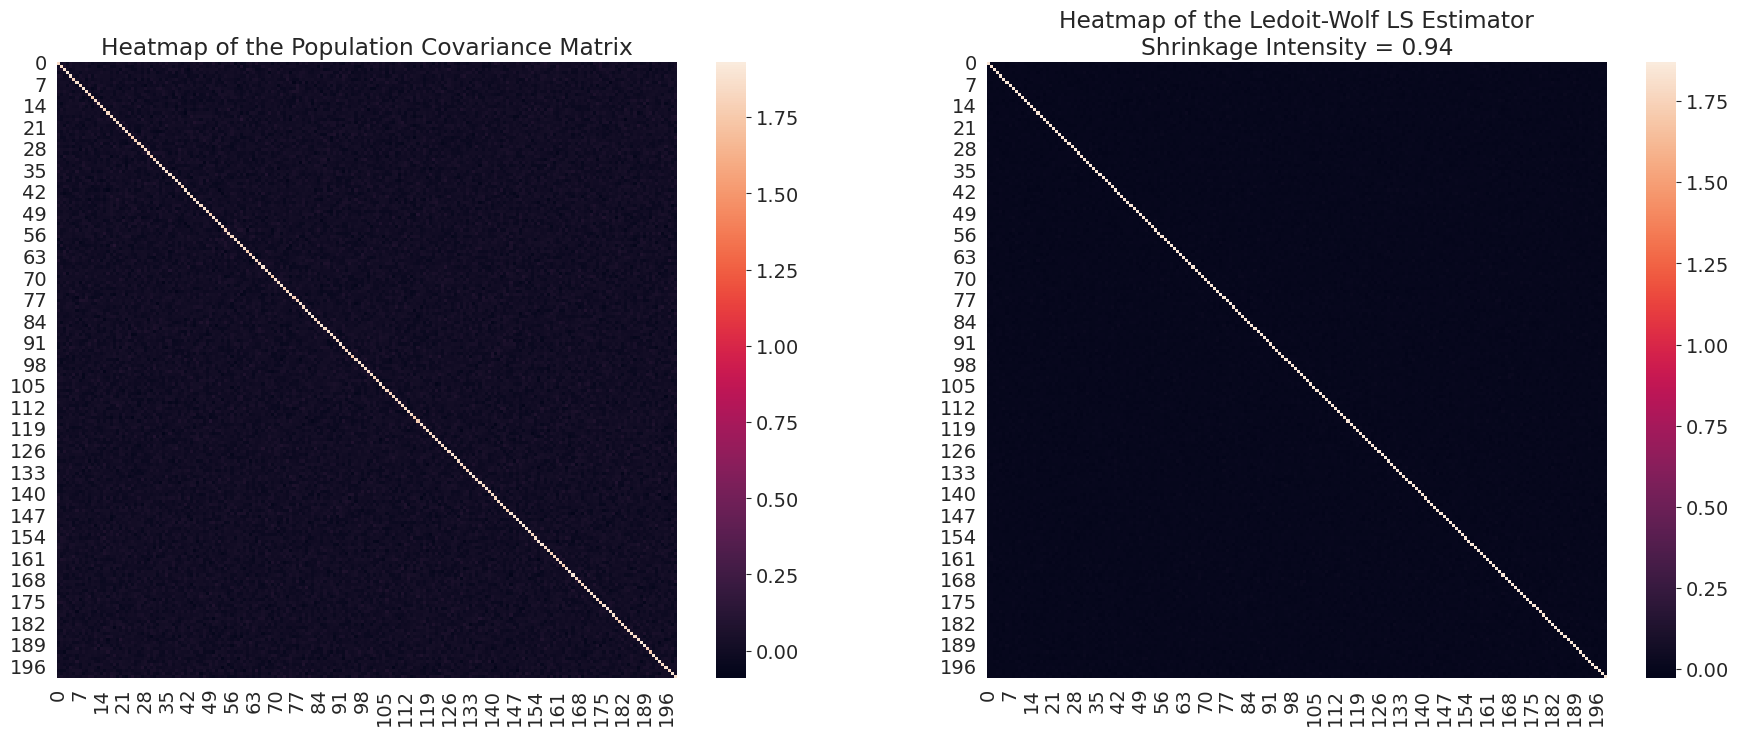

In [14]:
#### Visualizations
LOE.plot_spectrum(plot_type='histogram')
LOE.plot_scree()
LOE.plot_heatmap(cov_matrix='sample_cov') ## Compare Population vs Sample cov matrix
LOE.plot_heatmap(cov_matrix='lw_cov')     ## Compare Population cov matric ws Ledoit-Wolf LS estimator